In [ ]:
 import keras
print("Keras version:", keras.__version__)

Keras version: 3.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI ML-LastSem/Week4/Copy of Copy of devnagari digit.zip"
extract_to = "/content/devnagari_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted! Contents:")
print(os.listdir(extract_to))

Extracted! Contents:
['DevanagariHandwrittenDigitDataset']


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from keras.utils import to_categorical

DATASET_ROOT = "/content/devnagari_data/DevanagariHandwrittenDigitDataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR  = os.path.join(DATASET_ROOT, "Test")

IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10


def load_images_from_folder(folder):
    """Load all images from folder, returning (images, labels) as numpy arrays."""
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map   = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")              # grayscale
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))            # resize to 28x28
            img = np.array(img) / 255.0                          # normalize to [0, 1]
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


print("Loading training data...")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)

print("Loading test data...")
x_test_raw, y_test_raw = load_images_from_folder(TEST_DIR)

print(f"\nTraining images: {x_train_raw.shape}, Labels: {y_train_raw.shape}")
print(f"Test images:     {x_test_raw.shape}, Labels: {y_test_raw.shape}")

Loading training data...
Loading test data...

Training images: (17000, 28, 28), Labels: (17000,)
Test images:     (3000, 28, 28), Labels: (3000,)


In [ ]:
idx = np.random.permutation(len(x_train_raw))
x_train_raw, y_train_raw = x_train_raw[idx], y_train_raw[idx]

In [ ]:
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test  shape:", x_test.shape)
print("y_test  shape:", y_test.shape)

x_train shape: (17000, 784)
y_train shape: (17000, 10)
x_test  shape: (3000, 784)
y_test  shape: (3000, 10)


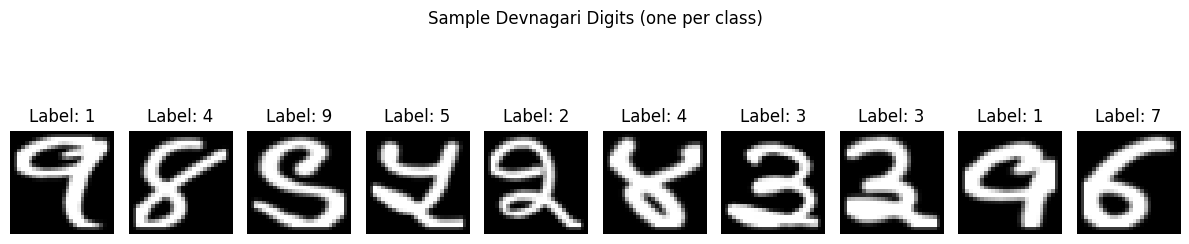

In [ ]:
# Visualise a few sample training images
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_raw[i * 180], cmap="gray")   # pick one from each class
    plt.title(f"Label: {y_train_raw[i * 180]}")
    plt.axis("off")
plt.suptitle("Sample Devnagari Digits (one per class)", y=1.02)
plt.tight_layout()
plt.show()

Architecture as specified in the worksheet:
- Flatten layer (784 inputs)
- Hidden layer 1: 64 neurons, sigmoid
- Hidden layer 2: 128 neurons, sigmoid
- Hidden layer 3: 256 neurons, sigmoid
- Output layer: 10 neurons, softmax

In [ ]:
from keras import Sequential
from keras.layers import Dense, Flatten, Input

model = Sequential([
    Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),   # 784-dim input

    Dense(64,  activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    Dense(256, activation="sigmoid"),

    Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # labels are one-hot encoded
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        verbose=1
    ),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2657 - loss: 2.1972
Epoch 1: val_loss improved from None to 1.02762, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4582 - loss: 1.8450 - val_accuracy: 0.7338 - val_loss: 1.0276
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7820 - loss: 0.8046
Epoch 2: val_loss improved from 1.02762 to 0.47889, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8036 - loss: 0.6627 - val_accuracy: 0.8362 - val_loss: 0.4789
Epoch 3/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8534 - loss: 0.4193
Epoch 3: val_loss improved from 0.47889 to 0.33757, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8671 - loss: 0.3834 - val_accuracy: 0.8915 -

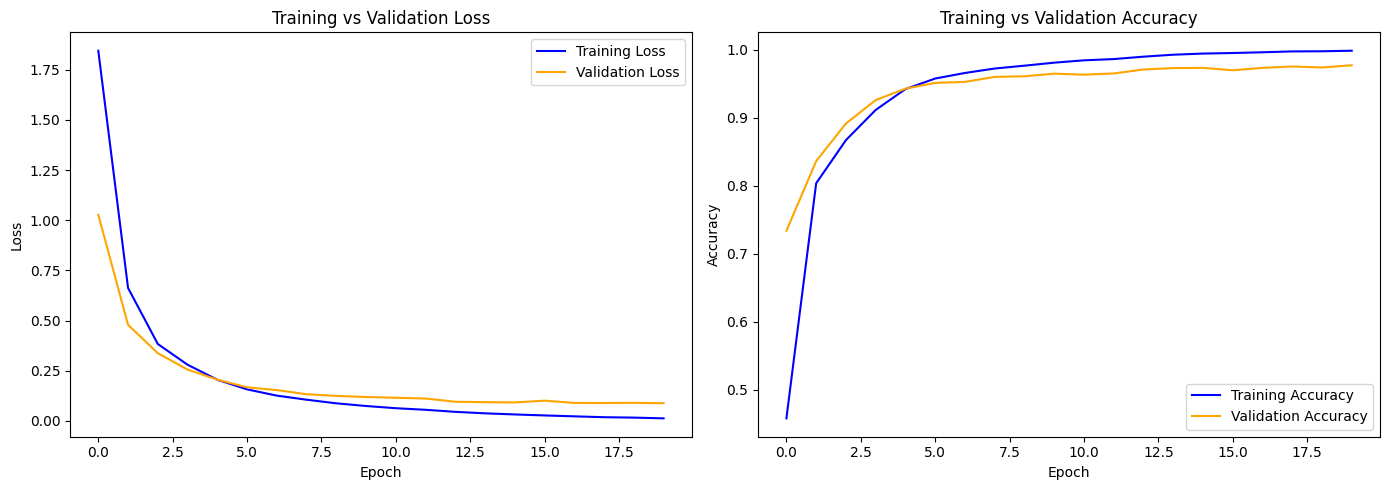

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"],     label="Training Loss",   color="blue")
axes[0].plot(history.history["val_loss"], label="Validation Loss", color="orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Training Accuracy",   color="blue")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc * 100:.2f}%)")

94/94 - 0s - 3ms/step - accuracy: 0.9780 - loss: 0.0818

Test Loss:     0.0818
Test Accuracy: 0.9780  (97.80%)


In [ ]:
# Save the model
model.save("devnagari_fcn_model.h5")
print("Model saved to devnagari_fcn_model.h5")

Model saved to devnagari_fcn_model.h5


In [ ]:
import keras

# Load the saved model
loaded_model = keras.saving.load_model("devnagari_fcn_model.h5")
print("Model loaded successfully.")

# Re-evaluate loaded model to confirm it works
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model - Test Loss:     {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f}  ({loaded_acc * 100:.2f}%)")

Model loaded successfully.
94/94 - 1s - 6ms/step - accuracy: 0.9780 - loss: 0.0818

Loaded Model - Test Loss:     0.0818
Loaded Model - Test Accuracy: 0.9780  (97.80%)


In [ ]:
# Get predicted probabilities for all test images
predictions = loaded_model.predict(x_test)

# Convert probabilities -> class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

for i in range(5):
    print(f"Image {i}: Predicted = {predicted_labels[i]},  True = {true_labels[i]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Image 0: Predicted = 0,  True = 0
Image 1: Predicted = 0,  True = 0
Image 2: Predicted = 0,  True = 0
Image 3: Predicted = 0,  True = 0
Image 4: Predicted = 0,  True = 0


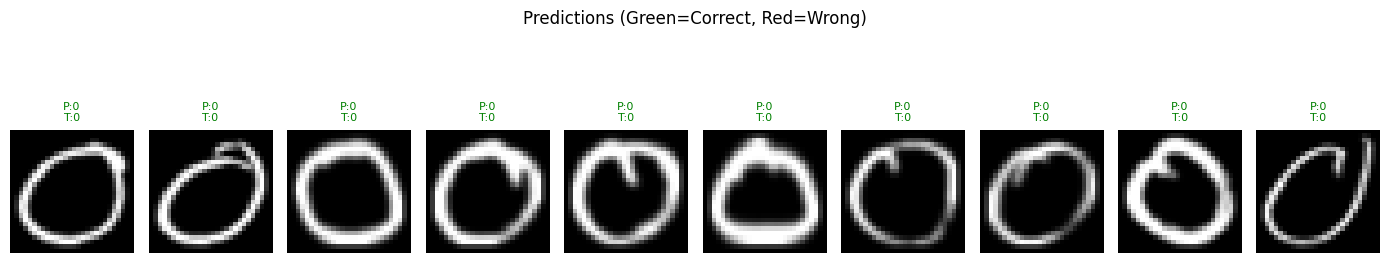

In [ ]:
plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test_raw[i], cmap="gray")
    color = "green" if predicted_labels[i] == true_labels[i] else "red"
    plt.title(f"P:{predicted_labels[i]}\nT:{true_labels[i]}", color=color, fontsize=8)
    plt.axis("off")
plt.suptitle("Predictions (Green=Correct, Red=Wrong)", y=1.05)
plt.tight_layout()
plt.show()